In [ ]:
!pip install info-nce-pytorch

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
sys.path.append('../../')

import phys_ml.visualization.vertex_visualization as vertvis
import phys_ml.visualization.base as vis
from phys_ml.analysis.vertex import *
from phys_ml.evaluation import vertex as verteval
from phys_ml.load_data.vertex import *
from phys_ml.trainer.vertex import *
from phys_ml.util import slurm_generate

## contents

&emsp;0&emsp;on real space  
&emsp;1&emsp;trained on all vertices  
&emsp;&emsp;1-1&emsp;simple autoencoder  
&emsp;&emsp;1-2&emsp;contrastive autoencoder  
&emsp;2&emsp;trained on only 2 phases  
&emsp;&emsp;2-1&emsp;exclude SC-phase  
&emsp;&emsp;&emsp;2-1-1&emsp;simple autoencoder  
&emsp;&emsp;&emsp;2-1-2&emsp;contrastive autoencoder  
&emsp;&emsp;2-2&emsp;exclude AFM-phase  
&emsp;&emsp;&emsp;2-2-1&emsp;simple autoencoder  
&emsp;&emsp;&emsp;2-2-2&emsp;contrastive autoencoder  
&emsp;&emsp;2-3&emsp;exclude FM-phase  
&emsp;&emsp;&emsp;2-3-1&emsp;simple autoencoder  
&emsp;&emsp;&emsp;2-3-2&emsp;contrastive autoencoder  
&emsp;3&emsp;trained on only 1 phase  
&emsp;&emsp;3-1&emsp;SC-phase  
&emsp;&emsp;3-2&emsp;AFM-phase  
&emsp;&emsp;3-3&emsp;FM-phase  
&emsp;4&emsp;correlation  
&emsp;5&emsp;convergence  

In [ ]:
# latent dim?
# 

## slurm

In [6]:
run_ids = ['1_1', '1_2', '2_1_1', '2_1_2', '2_2_1', '2_2_2', '2_3_1', '2_3_2', '3_1', '3_2', '3_3']

In [7]:
# ld=16 sbatch commands
for run_id in run_ids:
    print(f'sbatch vertex_{run_id}_s8000.slrm')

sbatch vertex_1_1_s8000.slrm
sbatch vertex_1_2_s8000.slrm
sbatch vertex_2_1_1_s8000.slrm
sbatch vertex_2_1_2_s8000.slrm
sbatch vertex_2_2_1_s8000.slrm
sbatch vertex_2_2_2_s8000.slrm
sbatch vertex_2_3_1_s8000.slrm
sbatch vertex_2_3_2_s8000.slrm
sbatch vertex_3_1_s8000.slrm
sbatch vertex_3_2_s8000.slrm
sbatch vertex_3_3_s8000.slrm


In [8]:
# ld=8 sbatch commands
for run_id in run_ids:
    print(f'sbatch vertex_{run_id}_s2000.slrm')

sbatch vertex_1_1_s2000.slrm
sbatch vertex_1_2_s2000.slrm
sbatch vertex_2_1_1_s2000.slrm
sbatch vertex_2_1_2_s2000.slrm
sbatch vertex_2_2_1_s2000.slrm
sbatch vertex_2_2_2_s2000.slrm
sbatch vertex_2_3_1_s2000.slrm
sbatch vertex_2_3_2_s2000.slrm
sbatch vertex_3_1_s2000.slrm
sbatch vertex_3_2_s2000.slrm
sbatch vertex_3_3_s2000.slrm


In [ ]:
# watch jobs
squeue -u shepp123

In [3]:
# config
base_dir = '/gpfs/data/fs71925/shepp123/'

def create_slurm(version: str, contrastive: bool = False, hidden_dims: list[int] = [128, 64, 32], epochs: int = -1,
                 sample_count_per_vertex: int = -1, subset: float|int|None = None, subset_type: list[str]|str|None = None,
                 batch_size: int = -1, qos: str = 'zen3_0512_a100x2', time: str = '24:00:00'):
    model_wrapper = 'VertexWrapper24x6InfoNCE' if contrastive else 'VertexWrapper24x6'
    model_name = 'ContrastiveAutoEncoder' if contrastive else 'AutoEncoderVertex'
    dataset = 'AutoEncoder24x6InfoNCEDataset' if contrastive else 'AutoEncoderVertex24x6Dataset'
    if epochs == -1:
        epochs = 50_000 if contrastive else 25_000
    if sample_count_per_vertex == -1:
        sample_count_per_vertex = 24_000
    if contrastive:
        sample_count_per_vertex = sample_count_per_vertex // 4
    if batch_size == -1:
        batch_size = 2048 if contrastive else 8192
    trainer_kwargs = {
        'config_name': 'confmod_auto_encoder.json', 
        'subconfig_name': 'AUTO_ENCODER_VERTEX_24X6', 
        'config_kwargs': {
            'path_train': base_dir + 'frgs_6d',
            'resume': 'run_results/' + version,
            'model_wrapper': model_wrapper,
            'model_name': model_name,
            'dataset': dataset,
            'hidden_dims': hidden_dims,
            'epochs': epochs,
            'sample_count_per_vertex': sample_count_per_vertex, 
            'test_ratio': 0.2, 
            'subset': subset, 
            'subset_type': subset_type,
            'subset_shuffle': False, 
            'devices': 'auto', 
            'device_type': 'gpu', 
            'num_dataloader_workers': 2, 
            'batch_size': batch_size,
        }
    }
    slurm_options = slurm_generate.SlurmOptions(qos=qos, time=time)
    slurm_kwargs = {'project_name': 'vertex_24x6', 'pyenv_dir': base_dir + 'PhysML/.venv', 
                    'trainer': 'vertex.VertexTrainer24x6', 'slurm_options': slurm_options, 'trainer_kwargs': trainer_kwargs}
    slurm_generate.create(script_name='vertex_' + version, **slurm_kwargs)


def create_all_scripts(s: int):
    create_slurm(version=f'1_1_s{s}', sample_count_per_vertex=s)
    create_slurm(version=f'1_2_s{s}', contrastive=True, sample_count_per_vertex=s)
    create_slurm(version=f'2_1_1_s{s}', sample_count_per_vertex=s, subset=0.8, subset_type=['afm', 'fm'])
    create_slurm(version=f'2_1_2_s{s}', contrastive=True, sample_count_per_vertex=s, subset=0.8, subset_type=['afm', 'fm'])
    create_slurm(version=f'2_2_1_s{s}', sample_count_per_vertex=s, subset=0.8, subset_type=['sc', 'fm'])
    create_slurm(version=f'2_2_2_s{s}', contrastive=True, sample_count_per_vertex=s, subset=0.8, subset_type=['sc', 'fm'])
    create_slurm(version=f'2_3_1_s{s}', sample_count_per_vertex=s, subset=0.8, subset_type=['afm', 'sc'])
    create_slurm(version=f'2_3_2_s{s}', contrastive=True, sample_count_per_vertex=s, subset=0.8, subset_type=['afm', 'sc'])
    create_slurm(version=f'3_1_s{s}', sample_count_per_vertex=s, subset=0.8, subset_type='sc')
    create_slurm(version=f'3_2_s{s}', sample_count_per_vertex=s, subset=0.8, subset_type='afm')
    create_slurm(version=f'3_3_s{s}', sample_count_per_vertex=s, subset=0.8, subset_type='fm')

In [4]:
s = 8000
create_all_scripts(s)

In [5]:
s = 2000
create_all_scripts(s)

## setup

In [ ]:
from sklearn import ensemble, svm


# load vertices
path_train = '../../../frgs_6d'
file_paths = AutoEncoderVertex24x6Dataset.get_filepaths(path_train, subset=None, subset_shuffle=False)[0]
vertices = AutoEncoderVertex24x6Dataset.load_vertex_files(file_paths)

# autoencoder
seed = 42
hidden_dims = [128, 64, 32]
train_samples_per_vertex = 24000
nce_train_samples = train_samples_per_vertex // 4
test_samples_per_vertex = 2000
config_kwargs = {
    'hidden_dims': hidden_dims,
    'epochs': 1000,
    'test_ratio': 0.2, 
    'devices': 'auto', 
    'num_dataloader_workers': 16, 
    'strategy': 'auto', 
    'batch_size': 8192 * 2,
}
dataset_kwargs = {
    'path_train': path_train, 
    'subset_shuffle': False, 
}

# phase classifier
pc_models = [
    # svm.SVC(verbose=True, random_state=seed + 1), 
    ensemble.RandomForestClassifier(n_jobs=-1, verbose=0, random_state=seed + 2),
]

In [ ]:
# general train sets
train_dataset = verteval.make_dataset(vertices, train_samples_per_vertex, dataset_kwargs)
nce_train_dataset = verteval.make_dataset(vertices, nce_train_samples, dataset_kwargs, dataset_class=AutoEncoder24x6InfoNCEDataset)
nce_train_dataset_subset = verteval.make_dataset(vertices, nce_train_samples, dataset_kwargs, subset=0.8, 
                                                 dataset_class=AutoEncoder24x6InfoNCEDataset)

# reconstruction filepaths
ex_sc_fps = AutoEncoderVertex24x6Dataset.get_filepaths(path_train, subset=0.8, subset_shuffle=dataset_kwargs['subset_shuffle'], 
                                                       subset_seed=seed, subset_type=['afm', 'fm'], file_paths=file_paths)[0]
ex_sc_fps = list(set(file_paths) - set(ex_sc_fps))
ex_afm_fps = AutoEncoderVertex24x6Dataset.get_filepaths(path_train, subset=0.8, subset_shuffle=dataset_kwargs['subset_shuffle'], 
                                                        subset_seed=seed, subset_type=['sc', 'fm'], file_paths=file_paths)[0]
ex_afm_fps = list(set(file_paths) - set(ex_afm_fps))
ex_fm_fps = AutoEncoderVertex24x6Dataset.get_filepaths(path_train, subset=0.8, subset_shuffle=dataset_kwargs['subset_shuffle'], 
                                                       subset_seed=seed, subset_type=['afm', 'sc'], file_paths=file_paths)[0]
ex_fm_fps = list(set(file_paths) - set(ex_fm_fps))
sc_fps = AutoEncoderVertex24x6Dataset.get_filepaths(path_train, subset=0.8, subset_shuffle=dataset_kwargs['subset_shuffle'], 
                                                    subset_seed=seed, subset_type='sc', file_paths=file_paths)[0]
sc_fps = list(set(file_paths) - set(sc_fps))
afm_fps = AutoEncoderVertex24x6Dataset.get_filepaths(path_train, subset=0.8, subset_shuffle=dataset_kwargs['subset_shuffle'], 
                                                     subset_seed=seed, subset_type='afm', file_paths=file_paths)[0]
afm_fps = list(set(file_paths) - set(afm_fps))
fm_fps = AutoEncoderVertex24x6Dataset.get_filepaths(path_train, subset=0.8, subset_shuffle=dataset_kwargs['subset_shuffle'], 
                                                    subset_seed=seed, subset_type='fm', file_paths=file_paths)[0]
fm_fps = list(set(file_paths) - set(fm_fps))

# test sets
test_dataset_full = verteval.make_dataset(vertices, test_samples_per_vertex, dataset_kwargs, dataset_class=AutoEncoder24x6InfoNCEDataset)
test_dataset_subset = verteval.make_test_from_train_dataset(vertices, path_train, dataset_kwargs, test_samples_per_vertex, nce_train_dataset_subset)


# evaluate models

In [ ]:
import pandas as pd
from tqdm.notebook import tqdm

base_path = '/gpfs/data/fs71925/shepp123/PhysML/saves/vertex_24x6/run_results/'

run_info = {
    # '1_1': (file_paths, nce_train_dataset, test_dataset_full), 
    # '1_2': (file_paths, nce_train_dataset, test_dataset_full), 
    '2_1_1': (ex_sc_fps, nce_train_dataset_subset, test_dataset_subset), 
    '2_1_2': (ex_sc_fps, nce_train_dataset_subset, test_dataset_subset), 
    # '2_2_1': (ex_afm_fps, nce_train_dataset_subset, test_dataset_subset), 
    # '2_2_2': (ex_afm_fps, nce_train_dataset_subset, test_dataset_subset), 
    # '2_3_1': (ex_fm_fps, nce_train_dataset_subset, test_dataset_subset), 
    # '2_3_2': (ex_fm_fps, nce_train_dataset_subset, test_dataset_subset), 
    # '3_1': (sc_fps, nce_train_dataset_subset, test_dataset_subset), 
    # '3_2': (afm_fps, nce_train_dataset_subset, test_dataset_subset), 
    # '3_3': (fm_fps, nce_train_dataset_subset, test_dataset_subset),
}

reconstruction_results = []
classification_results = []
sample_counts = [24_000, 8_000, 2_000]
total = len(run_info) * len(sample_counts)
with tqdm(total=total, desc='Evaluation') as prog:
    for run_id, (recon_files, train_data, test_data) in run_info.items():
        for s in sample_counts:
            run_name =  f'{run_id}_32' if s == 24_000 else f'{run_id}_s{s}'
            prog.set_description(f'Evaluating {run_name}')
            save_path = base_path + run_name
            rmses = verteval.mean_rmse(file_paths, vertices, save_path)
            reconstruction_results.extend([
                {'run_id': run_id, 's': s, 'tp': tp, 'rmse': rmse} for tp, rmse in rmses.items()
            ])
            pc = PhaseClassification(save_path, pc_models, run_name)
            pc.train(nce_train_dataset)
            model_scores = pc.evaluate_classifiers(test_dataset_full, print_conf_mat=False)
            classification_results.append({'run_id': run_id, 's': s, 'f1': list(model_scores.values())[0][0]['f1']})
            prog.update()

rmse_df = pd.DataFrame(reconstruction_results)
rmse_df.to_csv(base_path + 'reconstruction_results_s.csv', index=False)
classification_df = pd.DataFrame(classification_results)
classification_df.to_csv(base_path + 'classification_results_s.csv', index=False)

# show results

In [6]:
base_path = '/gpfs/data/fs71925/shepp123/PhysML/saves/vertex_24x6/run_results/'

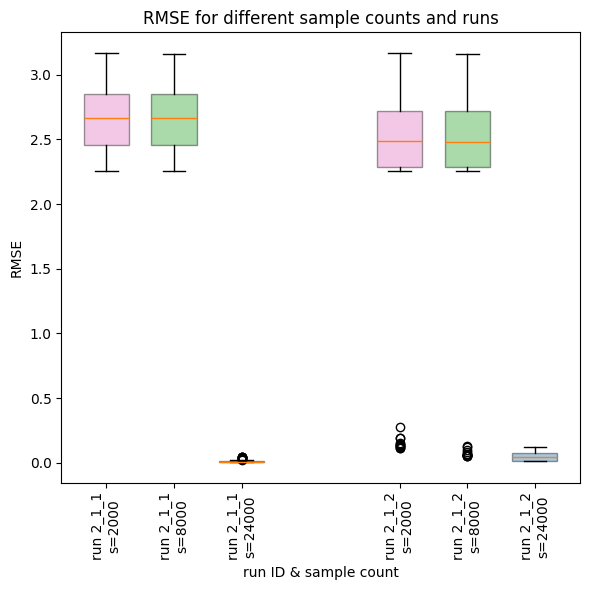

tp      rmse
run_id s                    
2_1_1  2000   0.25  2.676035
       8000   0.25  2.674256
       24000  0.25  0.013185
2_1_2  2000   0.25  2.063470
       8000   0.25  2.042674
       24000  0.25  0.050142

In [12]:
# plot 1: rmses for all models as boxplots in a single plot, group by (latent dimension, loss-type), color by (latent dimension, loss-type)
rmse_df = pd.read_csv(base_path + 'reconstruction_results_s.csv')
verteval.plot_all_rmses(rmse_df, 's', figsize=(6, 6))

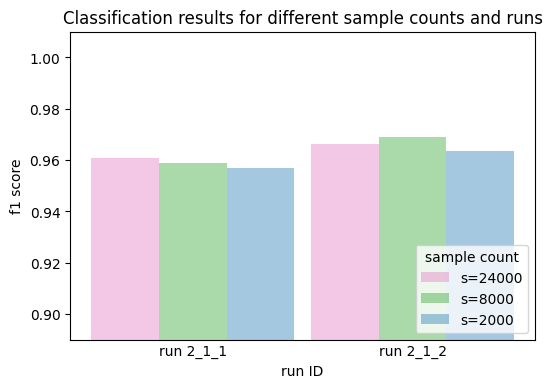

f1
run_id s              
2_1_1  24000  0.960729
       8000   0.958727
       2000   0.956765
2_1_2  24000  0.966148
       8000   0.968983
       2000   0.963471

In [13]:
# plot 2: bar plot classification f1 for all models, group by (latent dimension, loss-type), color by (latent dimension, loss-type)
classification_df = pd.read_csv(base_path + 'classification_results_s.csv')
verteval.plot_classification_results(classification_df, 's')